# **Machine Learning–Based Employee Attrition Prediction and Risk Scoring System**

## **Problem Statement**

Palo Alto Networks currently lacks a systematic, data-driven way to anticipate employee attrition. HR teams are often caught off guard by sudden resignations, including from high-performing or critical employees, and retention efforts tend to be reactive such as counter-offers made after an employee has already decided to leave. There is no quantitative risk score to flag at-risk employees in advance, and no clear visibility into the key factors driving attrition.

This project aims to build a machine learning model to predict the likelihood of an employee leaving the organization, and generate risk scores that enable:

- Early identification of high-risk employees
- Targeted, proactive retention interventions
- Data-driven workforce planning

In [1]:
import math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import duckdb
import seaborn as sns
from scipy import stats
from scipy.stats import ttest_ind
from scipy.stats import chi2_contingency
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, ConfusionMatrixDisplay

## **Data Overview & Sanity Checks**

In [2]:
df = pd.read_csv('Palo Alto Networks.csv')
df

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,1,Travel_Rarely,1102,Sales,1,2,Life Sciences,2,Female,...,3,1,0,8,0,1,6,4,0,5
1,49,0,Travel_Frequently,279,Research & Development,8,1,Life Sciences,3,Male,...,4,4,1,10,3,3,10,7,1,7
2,37,1,Travel_Rarely,1373,Research & Development,2,2,Other,4,Male,...,3,2,0,7,3,3,0,0,0,0
3,33,0,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,4,Female,...,3,3,0,8,3,3,8,7,3,0
4,27,0,Travel_Rarely,591,Research & Development,2,1,Medical,1,Male,...,3,4,1,6,3,3,2,2,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,0,Travel_Frequently,884,Research & Development,23,2,Medical,3,Male,...,3,3,1,17,3,3,5,2,0,3
1466,39,0,Travel_Rarely,613,Research & Development,6,1,Medical,4,Male,...,3,1,1,9,5,3,7,7,1,7
1467,27,0,Travel_Rarely,155,Research & Development,4,3,Life Sciences,2,Male,...,4,2,1,6,0,3,6,2,0,3
1468,49,0,Travel_Frequently,1023,Sales,2,3,Medical,4,Male,...,3,4,0,17,3,2,9,6,0,8


In [3]:
print(f'Number of duplicates: {df.duplicated().sum()}')
print(f'Number of missing values: {df.isnull().sum().sum()}')

Number of duplicates: 0
Number of missing values: 0


In [4]:
df.describe()

,Age,Attrition,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,0.161224,802.485714,9.192517,2.912925,2.721769,65.891156,2.729932,2.063946,2.728571,...,3.153741,2.712245,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,0.367863,403.509100,8.106864,1.024165,1.093082,20.329428,0.711561,1.106940,1.102846,...,0.360824,1.081209,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,0.000000,102.000000,1.000000,1.000000,1.000000,30.000000,1.000000,1.000000,1.000000,...,3.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,0.000000,465.000000,2.000000,2.000000,2.000000,48.000000,2.000000,1.000000,2.000000,...,3.000000,2.000000,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,0.000000,802.000000,7.000000,3.000000,3.000000,66.000000,3.000000,2.000000,3.000000,...,3.000000,3.000000,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,0.000000,1157.000000,14.000000,4.000000,4.000000,83.750000,3.000000,3.000000,4.000000,...,3.000000,4.000000,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1.000000,1499.000000,29.000000,5.000000,4.000000,100.000000,4.000000,5.000000,4.000000,...,4.000000,4.000000,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [5]:
# Creating a primary key (EmpId) since the dataset has no unique identifier for employees
df = df.reset_index(names='EmpId')

## **Exploratory Data Analysis (EDA)**

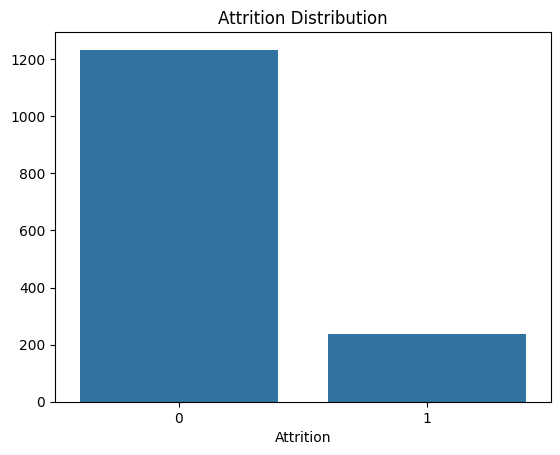

In [6]:
sns.barplot(x=df['Attrition'].value_counts().index,y=df['Attrition'].value_counts().values)
plt.title('Attrition Distribution')
plt.show()

The majority of employees have not left the company, while a smaller proportion have left the company.

In [7]:
# Groups related columns into one grid instead of plotting each column separately
def plot_group(cols, n_cols=3, is_categorical=None):
    n_rows = math.ceil(len(cols) / n_cols)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(7*n_cols, 6*n_rows))
    axes = axes.flatten()
    
    for ax, col in zip(axes, cols):
        if df[col].dtype == 'object' or df[col].nunique() <= 10:
            sns.countplot(data=df, x=col, ax=ax, order=df[col].value_counts().index)
        else:
            sns.histplot(df[col], kde=True, ax=ax)
        ax.set_title(col)
        ax.tick_params(axis='x', rotation=30)
    
    for ax in axes[len(cols):]:
        ax.set_visible(False)
    
    plt.tight_layout()
    plt.show()

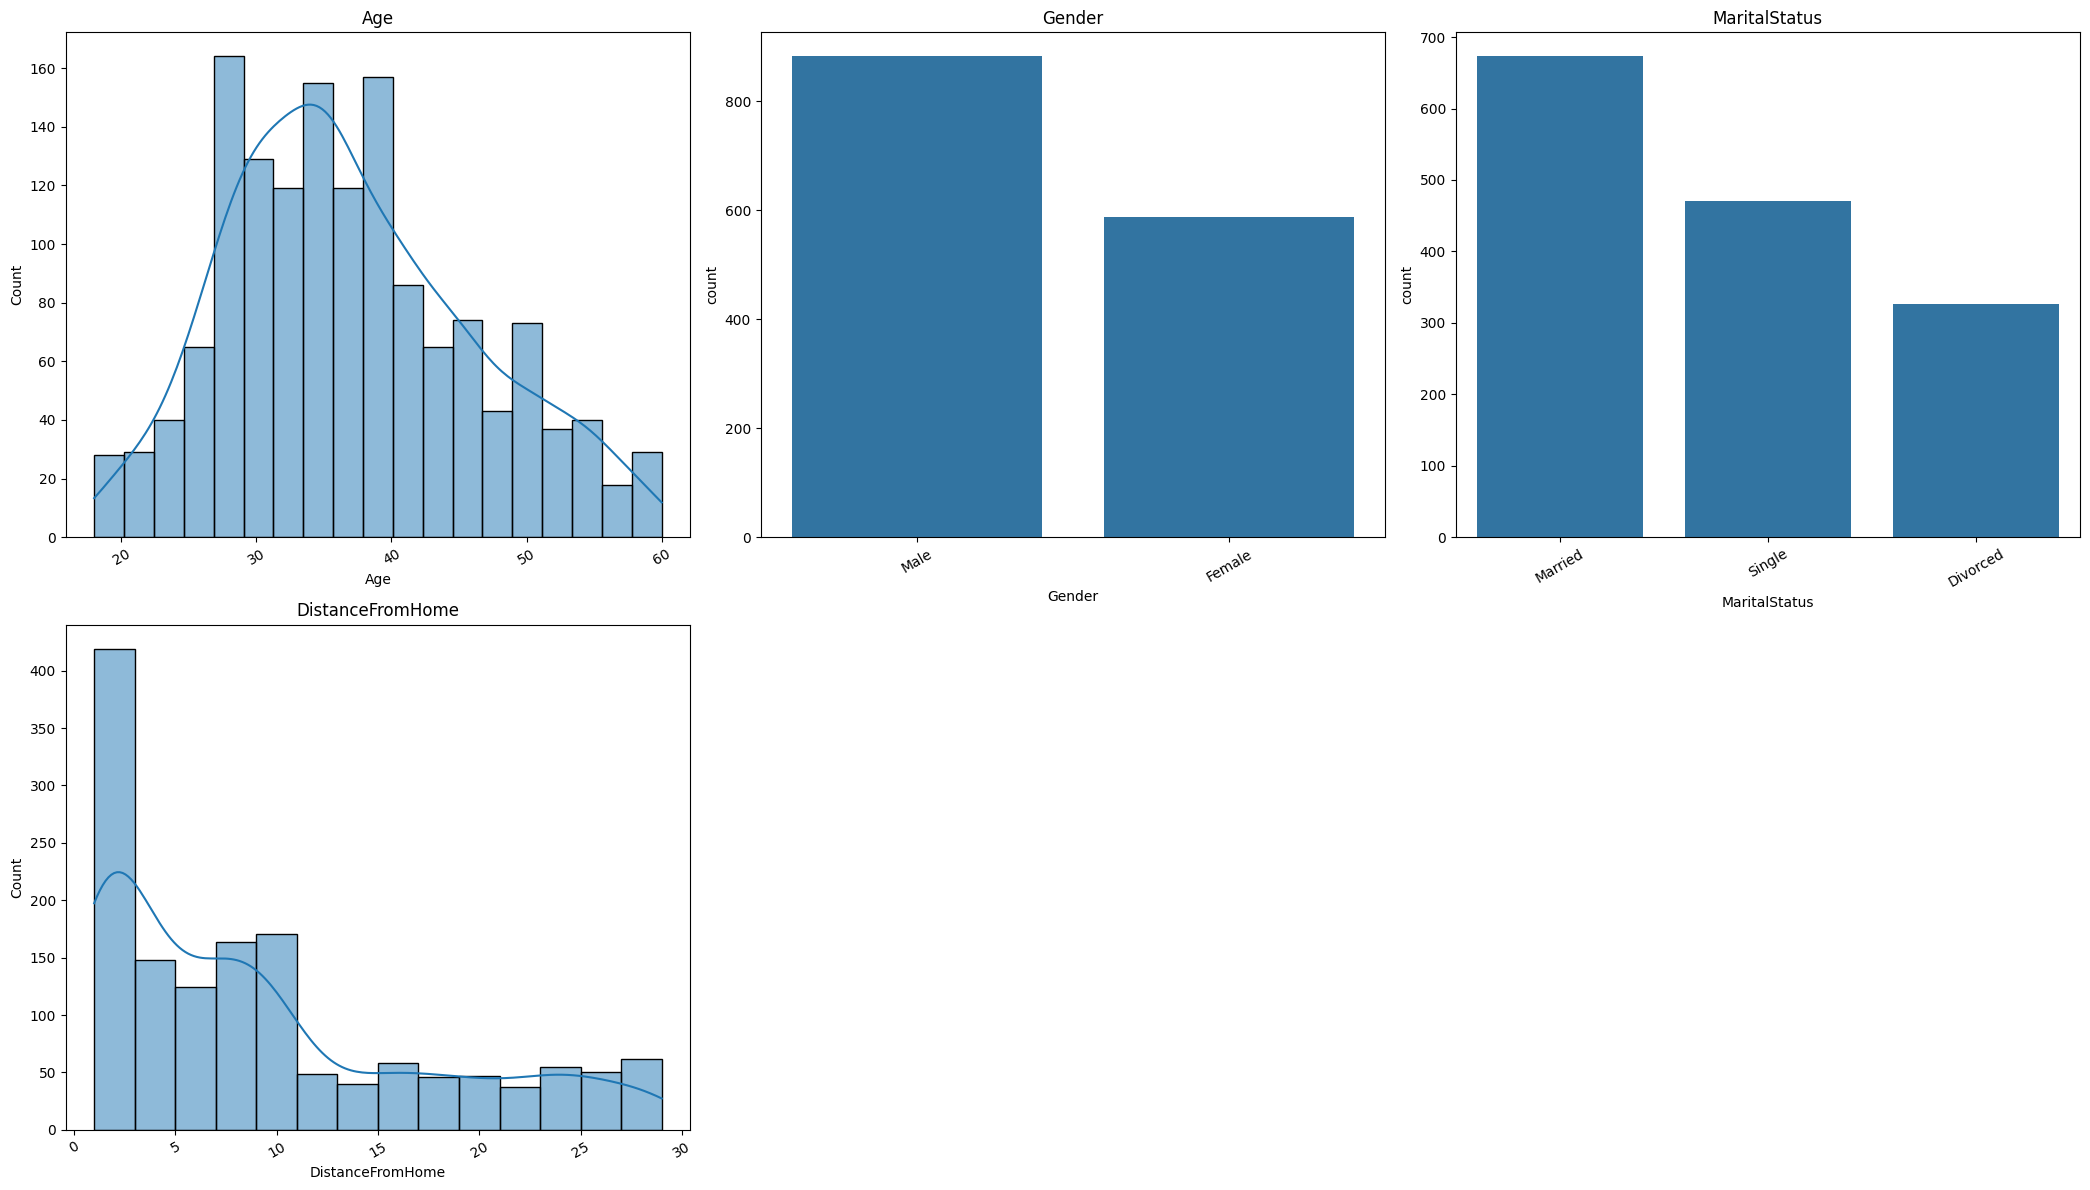

In [8]:
comp_cols = ['Age','Gender','MaritalStatus','DistanceFromHome']
plot_group(comp_cols)

### Demographics

- **Age** is right-skewed, with most employees concentrated between 25-40 years, and a long tail toward older employees (50+).
- **Gender** distribution is imbalanced, with roughly 60% Male vs 40% Female.
- **MaritalStatus** shows Married employees as the largest group, followed by Single, then Divorced.
- **DistanceFromHome** is heavily right-skewed, most employees live close to work (0-10 km), with a smaller number commuting much farther (20-30 km).

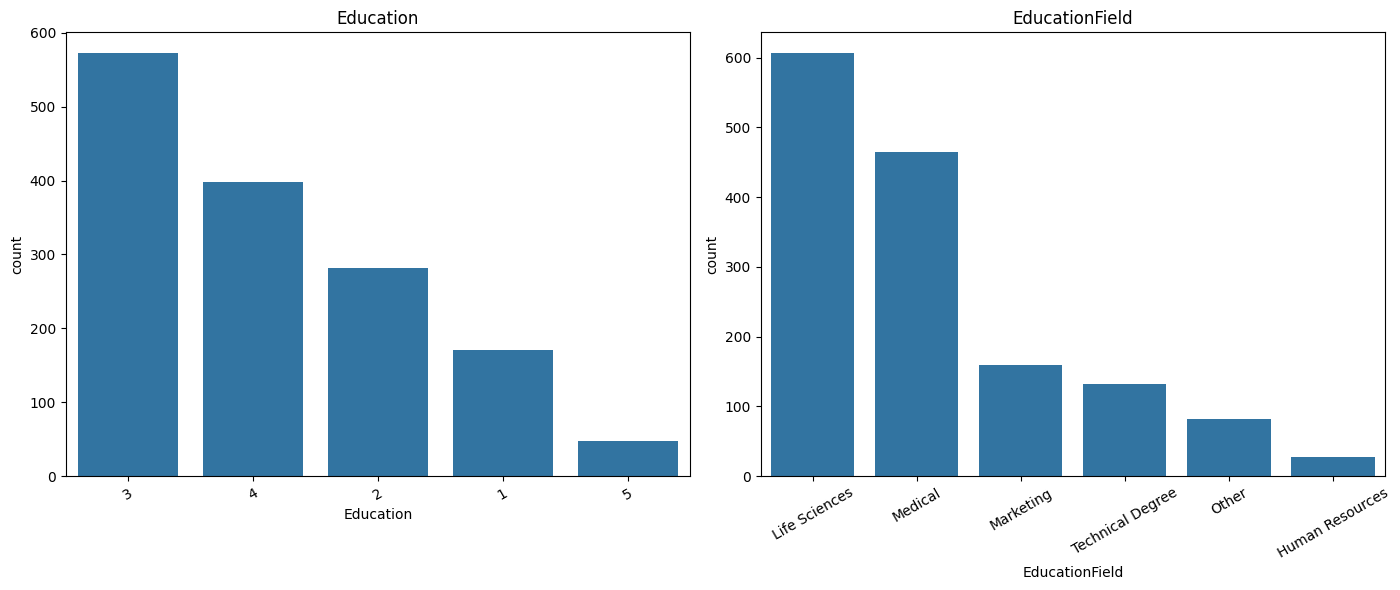

In [9]:
comp_cols = ['Education', 'EducationField']
plot_group(comp_cols)

### Education

- **Education** level is skewed toward Bachelor's (3) and Master's (4), with fewer employees at the extremes Below College (1) and Doctor (5).
- **EducationField** is dominated by Life Sciences and Medical, together accounting for the majority of employees, while Human Resources and Other are the least common fields.

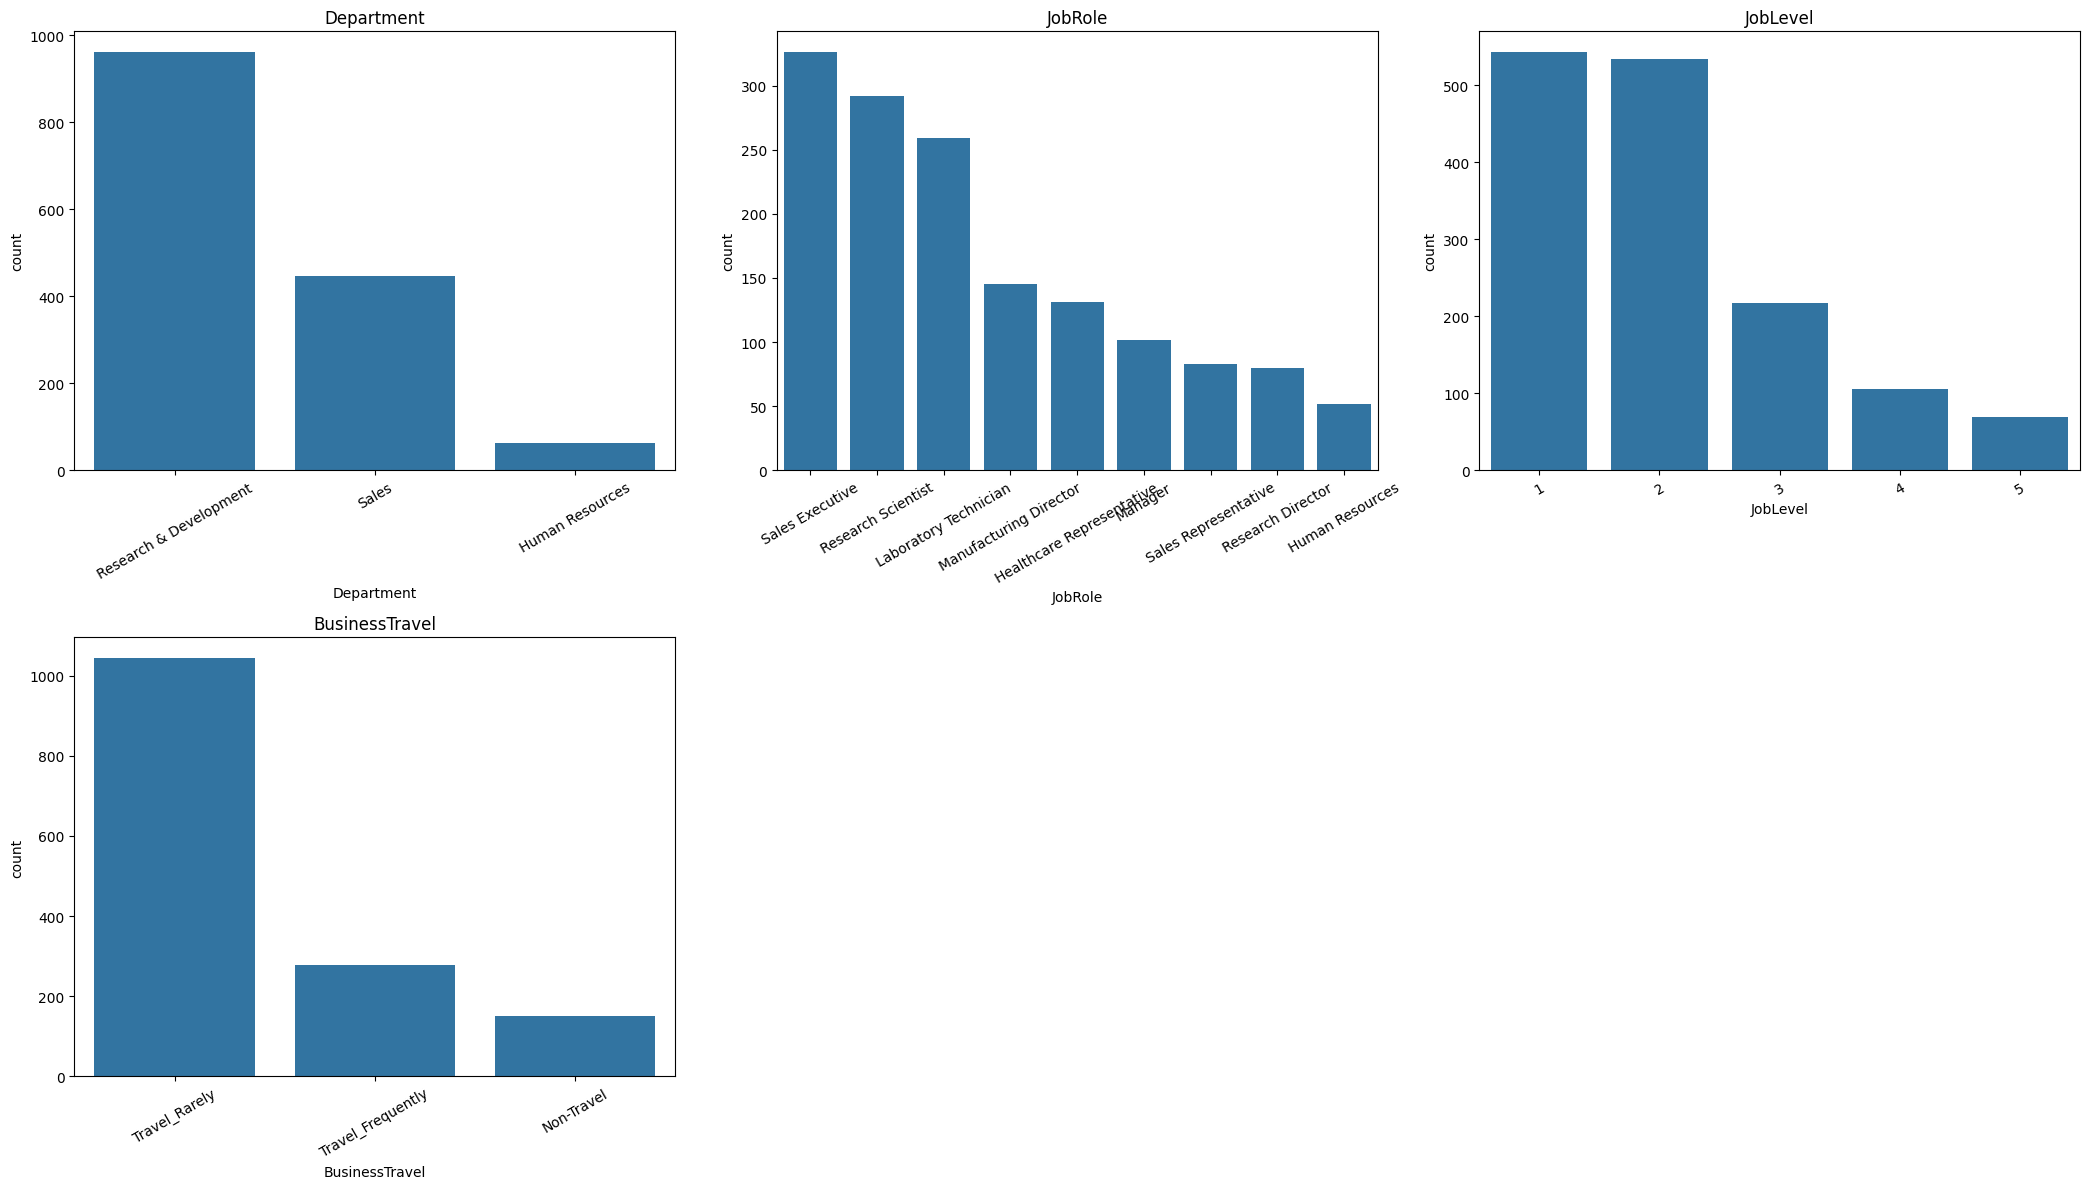

In [10]:
comp_cols  = ['Department', 'JobRole', 'JobLevel', 'BusinessTravel']
plot_group(comp_cols)

### Job Profile

- **Department** is dominated by Research & Development, followed by Sales, with Human Resources being a small minority.
- **JobRole** is led by Sales Executive and Research Scientist, while Human Resources and Research Director are the least common roles.
- **JobLevel** skews toward junior levels (1 and 2), with a steady drop-off at more senior levels (3-5), reflecting a typical bottom-heavy org structure.
- **BusinessTravel** shows most employees rarely travel, with a smaller group traveling frequently and very few not traveling at all.

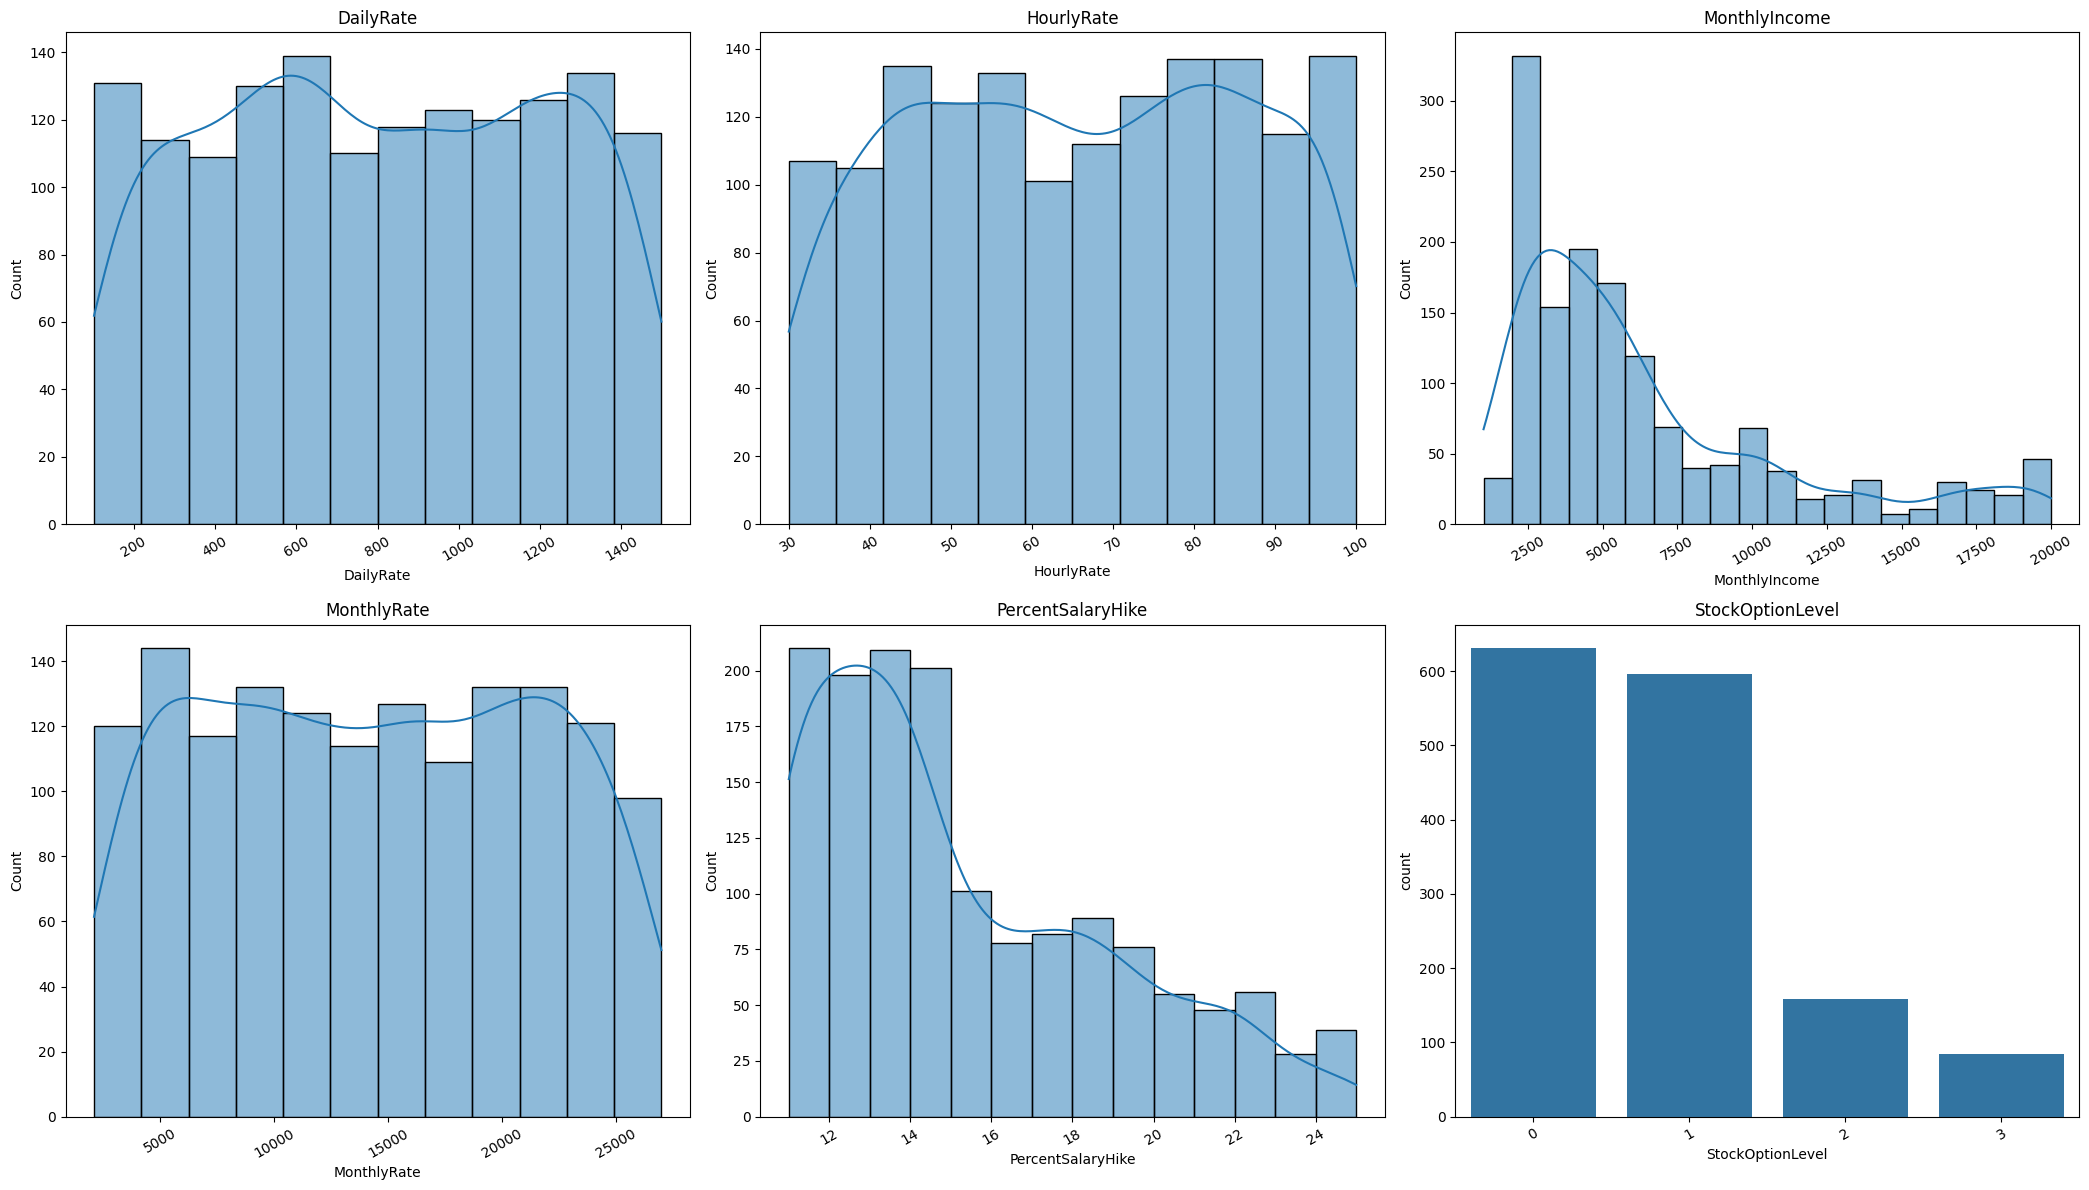

In [11]:
comp_cols = ['DailyRate', 'HourlyRate', 'MonthlyIncome', 'MonthlyRate', 'PercentSalaryHike', 'StockOptionLevel']
plot_group(comp_cols)

### Compensation

- **DailyRate**, **HourlyRate**, and **MonthlyRate** are all fairly uniformly distributed across their ranges, with no strong skew or concentration.
- **MonthlyIncome** is heavily right-skewed, most employees earn on the lower end (under 5000), with a long tail of higher earners up to 20000 likely reflecting seniority differences.
- **PercentSalaryHike** is right-skewed, concentrated between 11-15%, with fewer employees receiving larger hikes (20%+).
- **StockOptionLevel** is dominated by levels 0 and 1, while higher stock option levels (2, 3) are rare.

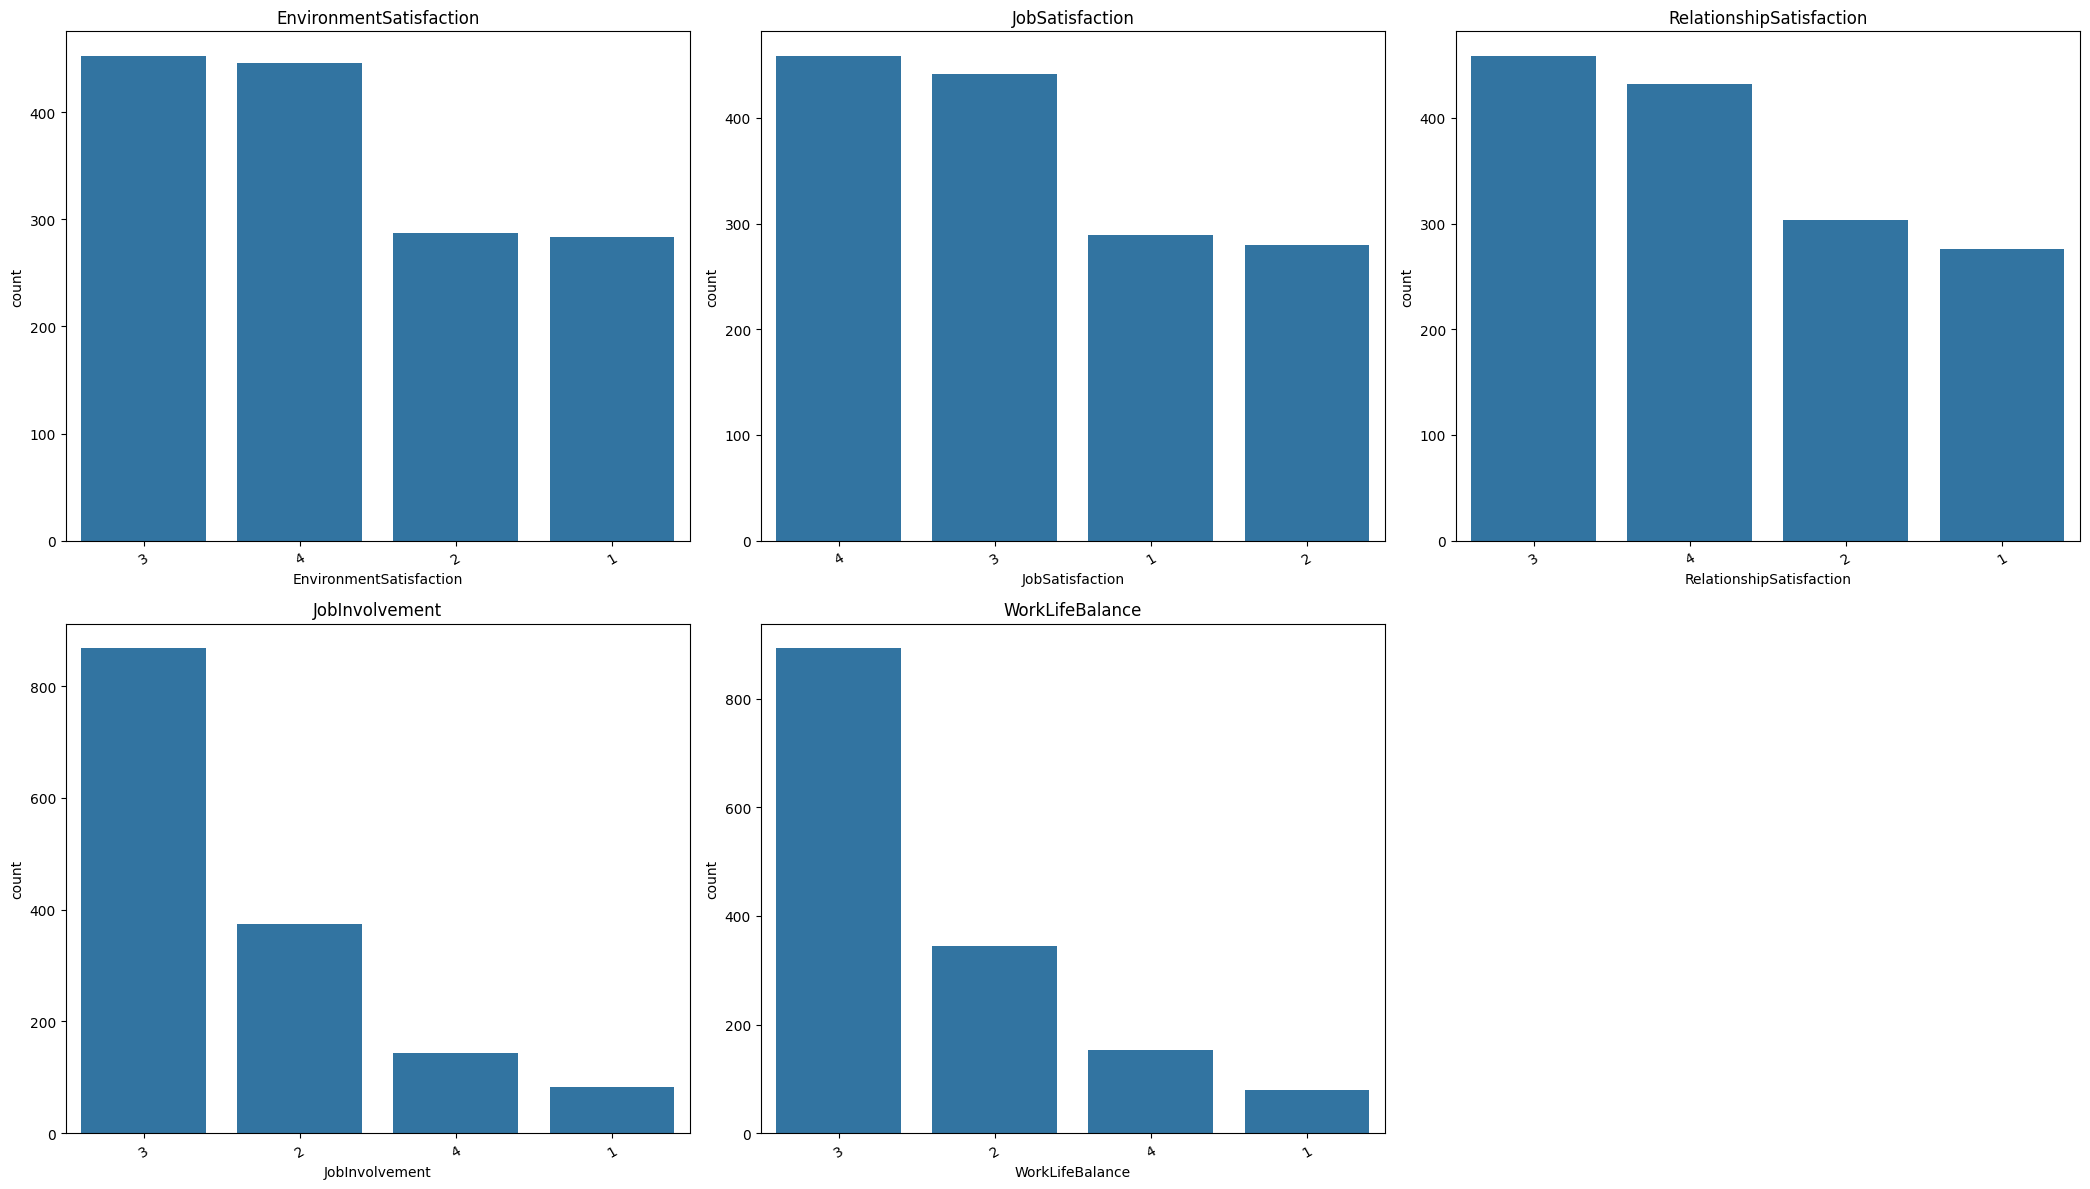

In [12]:
comp_cols = ['EnvironmentSatisfaction', 'JobSatisfaction', 'RelationshipSatisfaction', 'JobInvolvement', 'WorkLifeBalance']
plot_group(comp_cols)

### Satisfaction & Engagement

- **EnvironmentSatisfaction**, **JobSatisfaction**, and **RelationshipSatisfaction** show similar patterns, higher ratings (3-4) are more common than lower ones (1-2), suggesting most employees report reasonably positive satisfaction levels.
- **JobInvolvement** and **WorkLifeBalance** are both heavily skewed toward level 3, with relatively few employees at the extremes (1 or 4), indicating most employees fall into a "moderate" band rather than reporting very poor or very high involvement/balance.

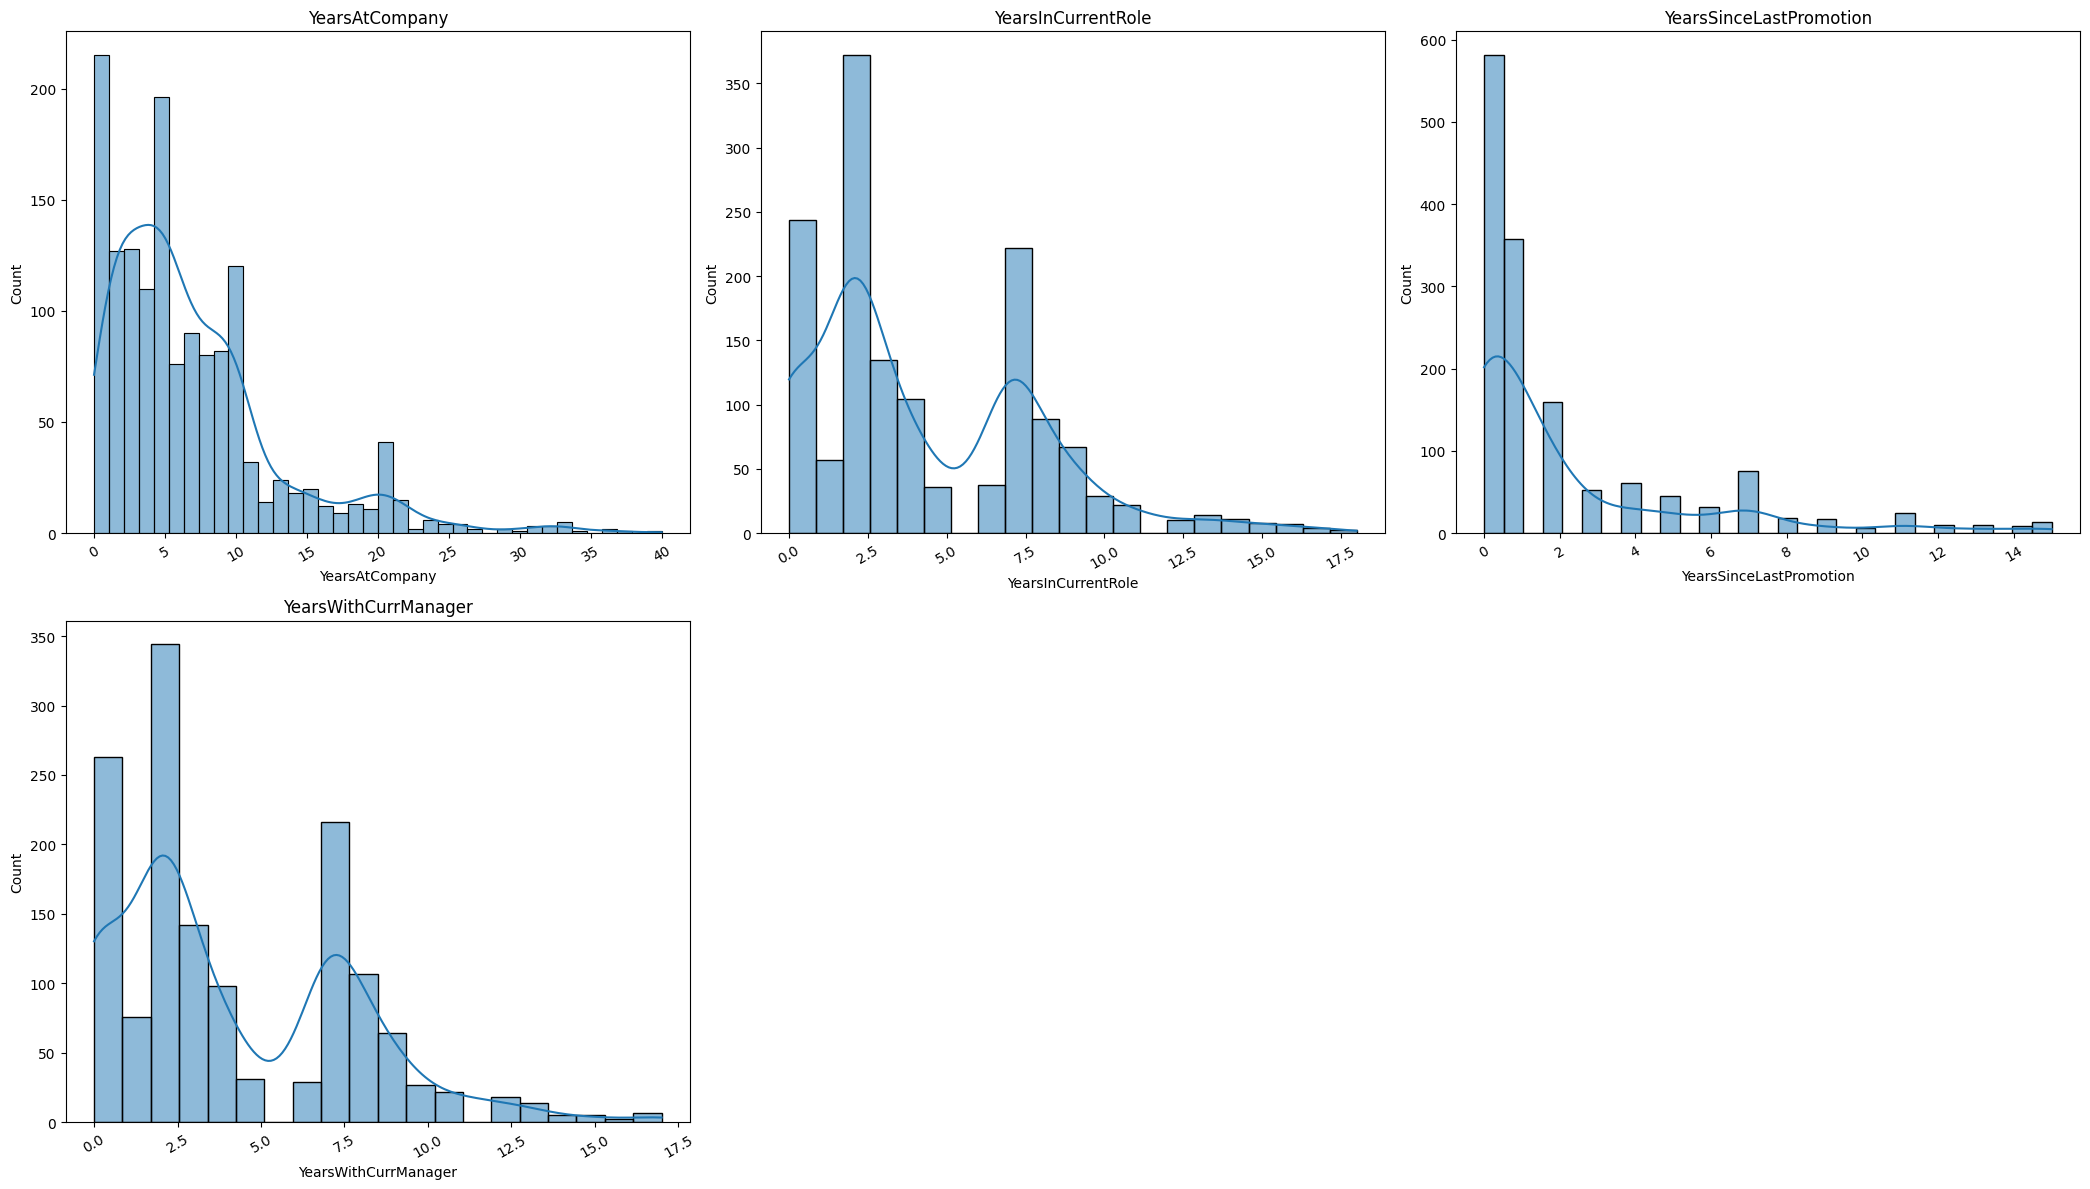

In [13]:
comp_cols = ['YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']
plot_group(comp_cols)

### Tenure at Company

- **YearsAtCompany** is right-skewed, most employees have been at the company under 10 years, with a small spike around 20 years and a long tail of longer-tenured employees.
- **YearsInCurrentRole** and **YearsWithCurrManager** show a similar bimodal pattern, a large cluster near 0-3 years and a secondary cluster around 7-8 years, suggesting distinct groups of recently-moved vs. longer-settled employees.
- **YearsSinceLastPromotion** is heavily right-skewed, most employees were promoted within the last 1-2 years, with far fewer going 5+ years without a promotion.

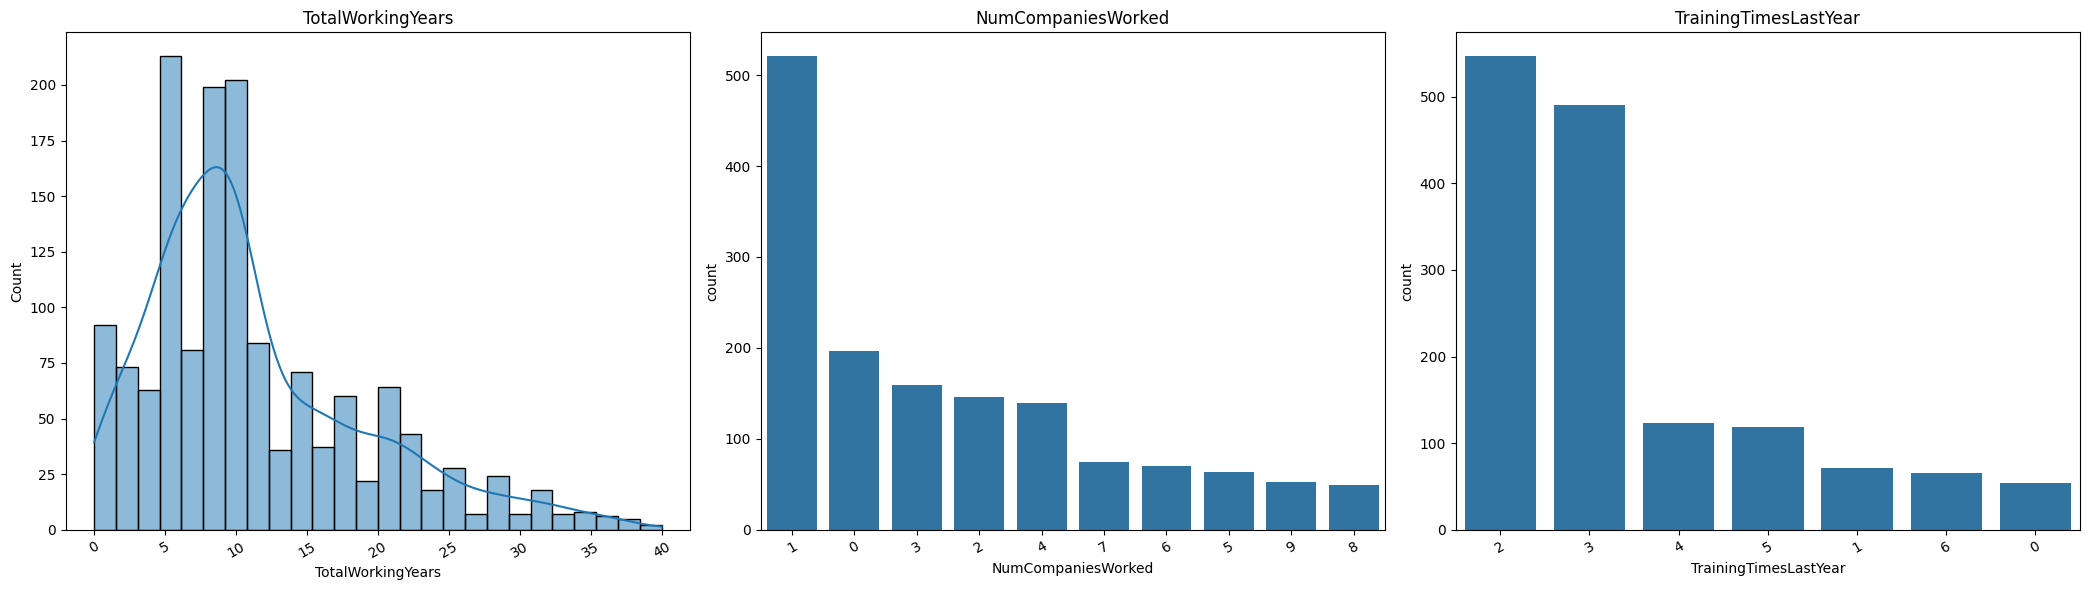

In [14]:
comp_cols = ['TotalWorkingYears', 'NumCompaniesWorked', 'TrainingTimesLastYear']
plot_group(comp_cols)

### Career History

- **TotalWorkingYears** is right-skewed, most employees have 5-10 years of overall experience, with a long tail extending to 40 years.
- **NumCompaniesWorked** is right-skewed, over half of employees have worked at only 0-1 prior companies, with a smaller number having worked at many (7+).
- **TrainingTimesLastYear** is concentrated around 2-3 trainings per year, with fewer employees receiving very little (0) or frequent (6+) training.

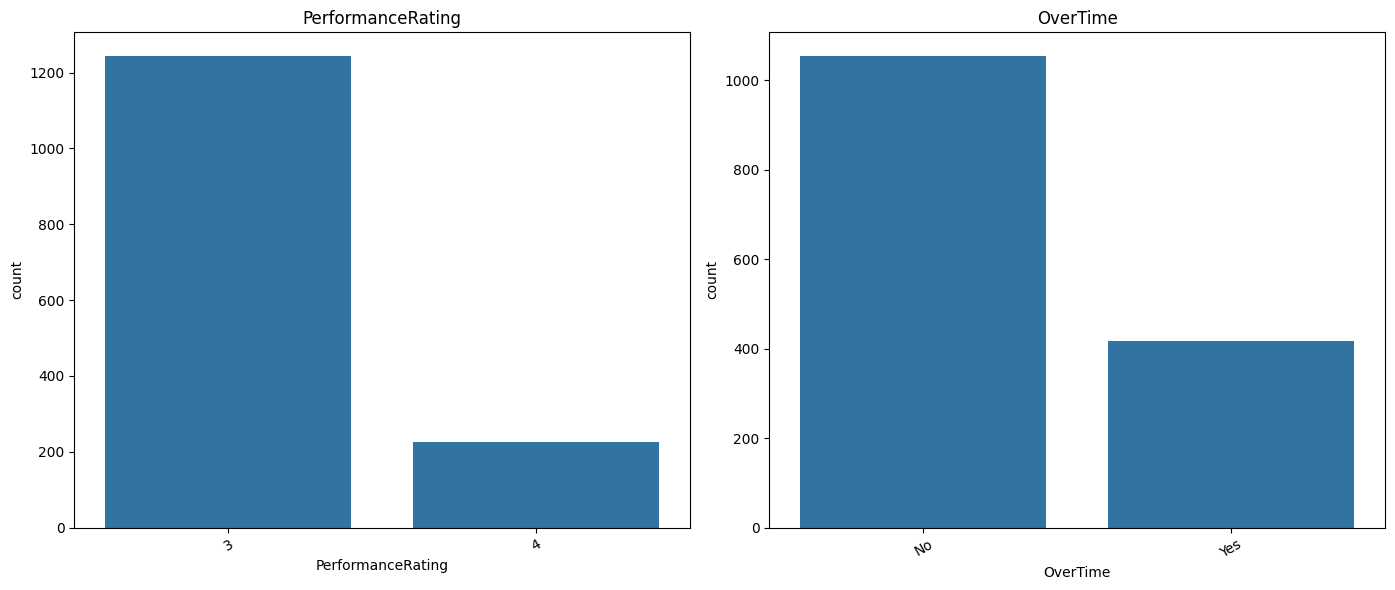

In [15]:
comp_cols = ['PerformanceRating', 'OverTime']
plot_group(comp_cols)

### Performance & Work Conditions

- **PerformanceRating** shows almost no variation, the vast majority of employees are rated 3, with very few rated 4, this column may carry limited predictive value due to its lack of spread.
- **OverTime** shows about 70% of employees do not work overtime, while roughly 30% do.

## **Feature Engineering & Selection**

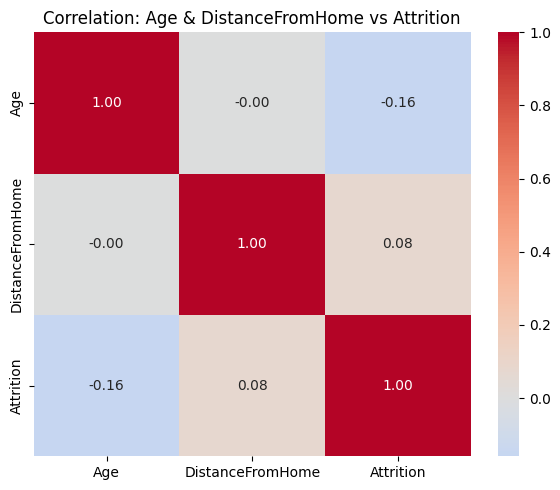

In [16]:
num_cols = ['Age', 'DistanceFromHome', 'Attrition']

plt.figure(figsize=(6, 5))
corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation: Age & DistanceFromHome vs Attrition')
plt.tight_layout()
plt.show()

In [17]:
# Reusable function to speed up t-testing/chi-squre test, since this will be run repeatedly across multiple variables and groups during feature selection
def run_ttest(cols, target='Attrition'):
    results = []
    for col in cols:
        left = df[df[target] == 1][col]
        stayed = df[df[target] == 0][col]
        t_stat, p = ttest_ind(left, stayed, equal_var=False)
        results.append({'Variable': col, 't_stat': t_stat, 'p_value': p})
    
    return pd.DataFrame(results).sort_values('p_value')

def run_chi2(cols, target='Attrition'):
    results = []
    for col in cols:
        contingency = pd.crosstab(df[col], df[target])
        chi2, p, dof, expected = chi2_contingency(contingency)
        results.append({'Variable': col, 'chi2_stat': chi2, 'p_value': p})
    
    return pd.DataFrame(results).sort_values('p_value')

In [18]:
ttest_results = run_ttest(['Age', 'DistanceFromHome'])
ttest_results

,Variable,t_stat,p_value
0,Age,-5.828012,1.379760e-08
1,DistanceFromHome,2.888183,4.136512e-03


In [19]:
chi_results = run_chi2(['Gender', 'MaritalStatus'])
chi_results

,Variable,chi2_stat,p_value
1,MaritalStatus,46.163677,9.455511e-11
0,Gender,1.116967,2.905724e-01


### Demographics — Summary

- **Age** and **DistanceFromHome** are both significantly related to Attrition, but the relationship is weak (correlation: -0.16 and 0.08).
- **MaritalStatus** is significantly related to Attrition and will be kept.
- **Gender** shows no significant relationship and is a candidate to drop.

In [20]:
chi_results = run_chi2(['Education', 'EducationField'])
chi_results

,Variable,chi2_stat,p_value
1,EducationField,16.024674,0.006774
0,Education,3.073961,0.545525


### Education — Summary

- **EducationField** is significantly related to Attrition and will be kept (p = 0.007).
- **Education** shows no significant relationship with Attrition and is a candidate to drop (p = 0.546).

In [21]:
chi_results = run_chi2(['Department', 'JobRole','JobLevel','BusinessTravel'])
chi_results

,Variable,chi2_stat,p_value
1,JobRole,86.190254,2.752482e-15
2,JobLevel,72.529013,6.634685e-15
3,BusinessTravel,24.182414,5.608614e-06
0,Department,10.796007,4.525607e-03


### Job Profile — Summary

- **JobRole**, **JobLevel**, **BusinessTravel**, and **Department** are all significantly related to Attrition and will be kept.
- **JobRole** and **JobLevel** show the strongest associations (lowest p-values), suggesting they may be more informative predictors within this group.

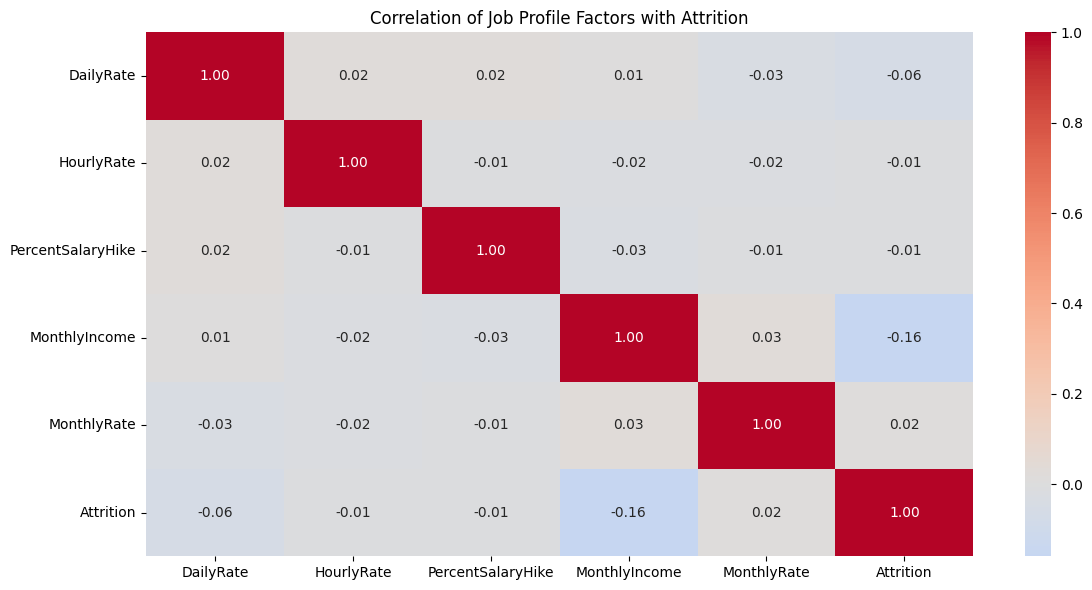

In [22]:
num_cols = ['DailyRate', 'HourlyRate', 'PercentSalaryHike','MonthlyIncome','MonthlyRate','Attrition']

plt.figure(figsize=(12, 6))
corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation of Job Profile Factors with Attrition')
plt.tight_layout()
plt.show()

In [23]:
ttest_results = run_ttest(['DailyRate', 'HourlyRate', 'PercentSalaryHike','MonthlyIncome','MonthlyRate'])
ttest_results

,Variable,t_stat,p_value
3,MonthlyIncome,-7.482622,4.433589e-13
0,DailyRate,-2.178882,3.003954e-02
4,MonthlyRate,0.575502,5.653438e-01
2,PercentSalaryHike,-0.504245,6.144301e-01
1,HourlyRate,-0.264769,7.913501e-01


In [24]:
chi_results = run_chi2(['StockOptionLevel'])
chi_results

,Variable,chi2_stat,p_value
0,StockOptionLevel,60.598301,4.379390e-13


### Compensation — Summary

- **MonthlyIncome** is significantly related to Attrition and will be kept (p = 4.43e-13, correlation: -0.16).
- **DailyRate** is statistically significant but shows a very weak correlation (p = 0.03, correlation: -0.06).
- **MonthlyRate**, **PercentSalaryHike**, and **HourlyRate** show no significant relationship with Attrition and are candidates to drop.
- **StockOptionLevel** is significantly related to Attrition and will be kept (p = 4.38e-13).

In [25]:
chi_results = run_chi2(['EnvironmentSatisfaction', 'JobSatisfaction', 'RelationshipSatisfaction', 'JobInvolvement', 'WorkLifeBalance'])
chi_results

,Variable,chi2_stat,p_value
3,JobInvolvement,28.492021,0.000003
0,EnvironmentSatisfaction,22.503881,0.000051
1,JobSatisfaction,17.505077,0.000556
4,WorkLifeBalance,16.325097,0.000973
2,RelationshipSatisfaction,5.241068,0.154972


### Satisfaction & Engagement — Summary

- **JobInvolvement**, **EnvironmentSatisfaction**, **JobSatisfaction**, and **WorkLifeBalance** are all significantly related to Attrition and will be kept.
- **RelationshipSatisfaction** shows no significant relationship with Attrition and is a candidate to drop (p = 0.155).

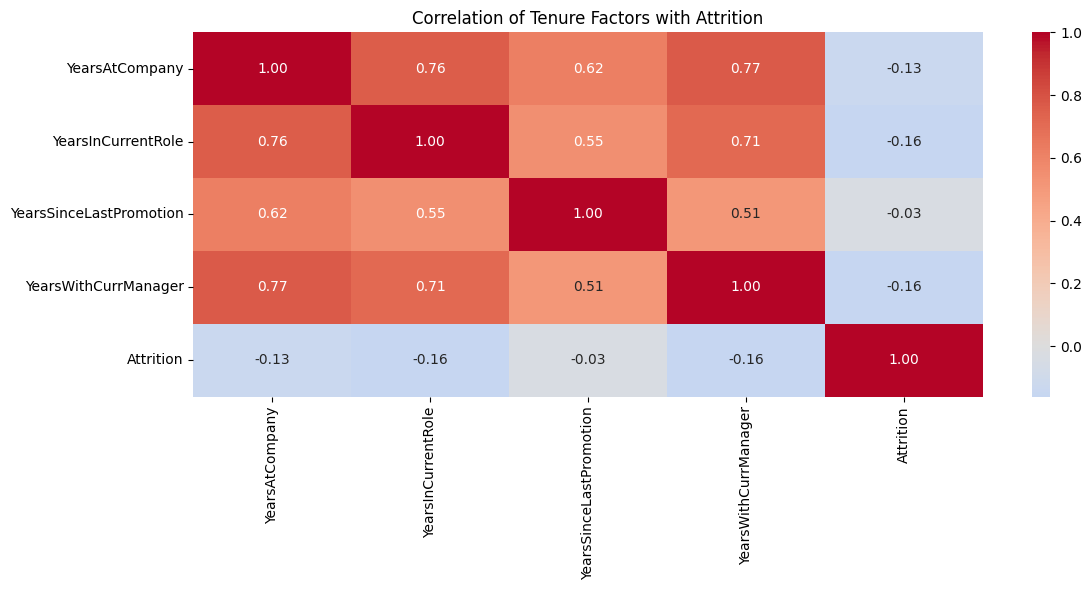

In [26]:
num_cols = ['YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager','Attrition']

plt.figure(figsize=(12, 6))
corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation of Tenure Factors with Attrition')
plt.tight_layout()
plt.show()

In [27]:
ttest_results = run_ttest(['YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager'])
ttest_results

,Variable,t_stat,p_value
1,YearsInCurrentRole,-6.847079,3.187390e-11
3,YearsWithCurrManager,-6.633399,1.185022e-10
0,YearsAtCompany,-5.282596,2.285905e-07
2,YearsSinceLastPromotion,-1.287927,1.986513e-01


### Tenure at Company — Summary
- **YearsAtCompany**, **YearsInCurrentRole**, and **YearsWithCurrManager** are all statistically significant, but they are highly correlated with each other (0.71-0.77), which may cause a multicollinearity issue.
- **YearsSinceLastPromotion** shows no significant relationship with Attrition and is a candidate to drop (p = 0.199).

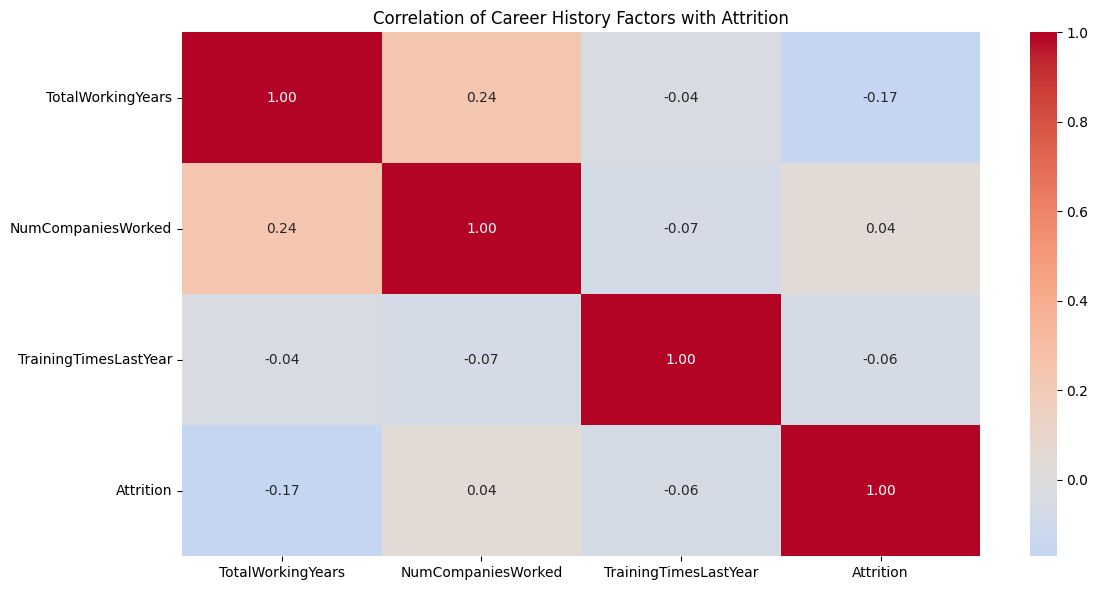

In [28]:
num_cols = ['TotalWorkingYears', 'NumCompaniesWorked', 'TrainingTimesLastYear', 'Attrition']

plt.figure(figsize=(12, 6))
corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation of Career History Factors with Attrition')
plt.tight_layout()
plt.show()

In [29]:
ttest_results =  run_ttest(['TotalWorkingYears', 'NumCompaniesWorked', 'TrainingTimesLastYear'])
ttest_results

,Variable,t_stat,p_value
0,TotalWorkingYears,-7.019179,1.159817e-11
2,TrainingTimesLastYear,-2.330522,2.036379e-02
1,NumCompaniesWorked,1.574651,1.163340e-01


### Career History — Summary

- **TotalWorkingYears** is significantly related to Attrition, though the relationship is weak (correlation: -0.17).
- **TrainingTimesLastYear** is technically significant (p = 0.02), but the correlation is negligible (-0.06).
- **NumCompaniesWorked** shows no significant relationship with Attrition and is a candidate to drop (p = 0.116).

In [30]:
chi_results = run_chi2(['PerformanceRating', 'OverTime'])
chi_results

,Variable,chi2_stat,p_value
1,OverTime,87.564294,8.158424e-21
0,PerformanceRating,0.000155,9.900745e-01


### Performance & Work Conditions — Summary

- **OverTime** shows a strong, highly significant relationship with Attrition and will be kept (p = 8.16e-21).
- **PerformanceRating** shows no relationship with Attrition and is a candidate to drop (p = 0.99).

## **Modeling**

In [31]:
# Creating a new df with only the variables that passed statistical testing (t-test/chi-square)
# against Attrition. These retained variables will be used for further feature engineering and modeling.
df_selected  = df[[
    'Age', 'DistanceFromHome', 'MaritalStatus','EducationField',
    'Department', 'JobRole', 'JobLevel', 'BusinessTravel',
    'MonthlyIncome', 'DailyRate', 'StockOptionLevel',
    'EnvironmentSatisfaction', 'JobSatisfaction', 'JobInvolvement', 'WorkLifeBalance',
    'YearsAtCompany', 'YearsInCurrentRole', 'YearsWithCurrManager',
    'TotalWorkingYears', 'TrainingTimesLastYear',
    'OverTime','Attrition'
]]
df_cat = df_selected.copy()

In [32]:
df_selected = pd.get_dummies(df_selected, columns=['MaritalStatus','EducationField','Department','JobRole','BusinessTravel'],drop_first=True)
df_selected['OverTime'] = df_selected['OverTime'].map({'Yes': 1, 'No': 0}).astype(int)

In [33]:
x = df_selected.drop(columns=['Attrition'])
y = df_selected['Attrition']
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42, stratify=y)

Before SMOTE: {0: 986, 1: 190}
After SMOTE: {0: 986, 1: 986}
              precision    recall  f1-score   support

           0       0.87      0.95      0.91       247
           1       0.50      0.26      0.34        47

    accuracy                           0.84       294
   macro avg       0.69      0.60      0.62       294
weighted avg       0.81      0.84      0.82       294

ROC-AUC: 0.754


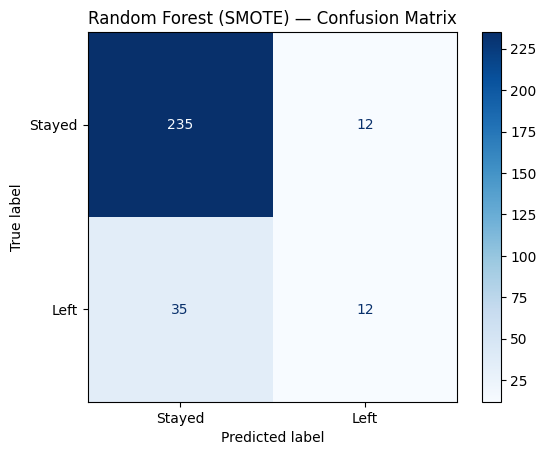

In [34]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
x_train_smote, y_train_smote = smote.fit_resample(x_train, y_train)

print("Before SMOTE:", y_train.value_counts().to_dict())
print("After SMOTE:", y_train_smote.value_counts().to_dict())

rf_smote = RandomForestClassifier(random_state=42)
rf_smote.fit(x_train_smote, y_train_smote)

y_pred_smote = rf_smote.predict(x_test)
y_pred_proba_smote = rf_smote.predict_proba(x_test)[:, 1]

print(classification_report(y_test, y_pred_smote))
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_proba_smote):.3f}")

cm_smote = confusion_matrix(y_test, y_pred_smote)
ConfusionMatrixDisplay(cm_smote, display_labels=['Stayed', 'Left']).plot(cmap='Blues')
plt.title('Random Forest (SMOTE) — Confusion Matrix')
plt.show()

              precision    recall  f1-score   support

           0       0.87      0.94      0.90       247
           1       0.44      0.26      0.32        47

    accuracy                           0.83       294
   macro avg       0.66      0.60      0.61       294
weighted avg       0.80      0.83      0.81       294

ROC-AUC: 0.750


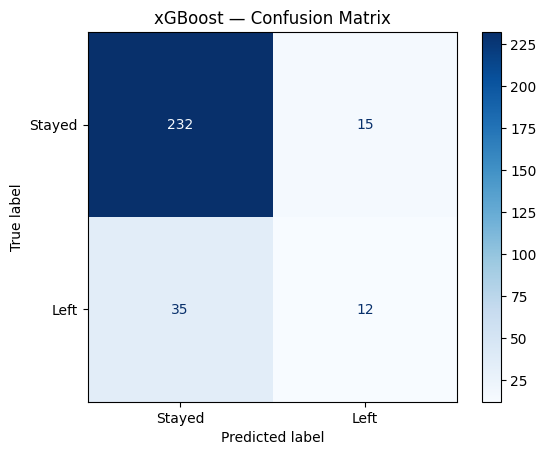

In [36]:
from xgboost import XGBClassifier

# scale_pos_weight = ratio of negative to positive class
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb = XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='logloss'
)
xgb.fit(x_train, y_train)

y_pred_xgb = xgb.predict(x_test)
y_pred_proba_xgb = xgb.predict_proba(x_test)[:, 1]

print(classification_report(y_test, y_pred_xgb))
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_proba_xgb):.3f}")

cm_xgb = confusion_matrix(y_test, y_pred_xgb)
ConfusionMatrixDisplay(cm_xgb, display_labels=['Stayed', 'Left']).plot(cmap='Blues')
plt.title('xGBoost — Confusion Matrix')
plt.show()

              precision    recall  f1-score   support

           0       0.90      0.91      0.91       247
           1       0.50      0.49      0.49        47

    accuracy                           0.84       294
   macro avg       0.70      0.70      0.70       294
weighted avg       0.84      0.84      0.84       294

ROC-AUC: 0.792


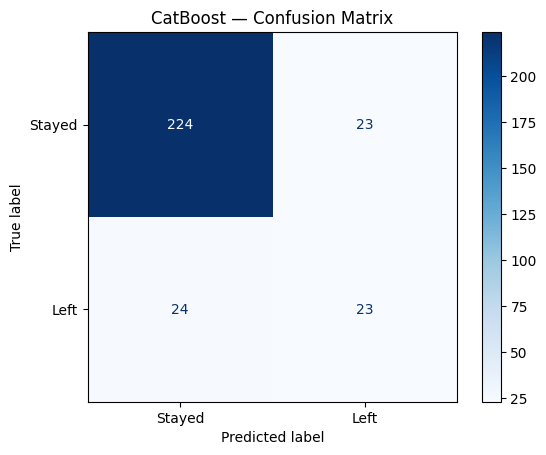

In [ ]:
from catboost import CatBoostClassifier
cat_features = ['MaritalStatus', 'EducationField', 'Department', 'JobRole', 'BusinessTravel', 'OverTime']

x_cat = df_cat.drop(columns=['Attrition'])
y_cat = df_cat['Attrition']

x_train_cat, x_test_cat, y_train_cat, y_test_cat = train_test_split(
    x_cat, y_cat, test_size=0.2, random_state=42, stratify=y_cat)

cb = CatBoostClassifier(cat_features=cat_features,auto_class_weights='Balanced',random_state=42,verbose=0)
cb.fit(x_train_cat, y_train_cat)

y_pred_cb = cb.predict(x_test_cat)
y_pred_proba_cb = cb.predict_proba(x_test_cat)[:, 1]

print(classification_report(y_test_cat, y_pred_cb))
print(f"ROC-AUC: {roc_auc_score(y_test_cat, y_pred_proba_cb):.3f}")

cm_cb = confusion_matrix(y_test_cat, y_pred_cb)
ConfusionMatrixDisplay(cm_cb, display_labels=['Stayed', 'Left']).plot(cmap='Blues')
plt.title('CatBoost — Confusion Matrix')
plt.show()

In [ ]:
importances = cb.get_feature_importance()
feature_names = x_train_cat.columns

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(data=importance_df, x='Importance', y='Feature', color='steelblue')
plt.title('CatBoost Feature Importance')
plt.tight_layout()
plt.show()

## Modeling Summary

Three models were trained to predict employee attrition: Random Forest, XGBoost, and CatBoost. Given the class imbalance in the target variable (Attrition), SMOTE and class-weighting were used during training, and models were evaluated primarily on ROC-AUC and class 1 (Left) recall/F1, rather than accuracy, since accuracy is misleading on imbalanced data.

| Model | Class 1 Recall | Class 1 F1 | ROC-AUC |
|---|---|---|---|
| Random Forest (SMOTE) | 0.26 | 0.34 | 0.754 |
| XGBoost | 0.26 | 0.32 | 0.750 |
| CatBoost | 0.49 | 0.49 | 0.792 |

**CatBoost performed best across all key metrics**, nearly doubling class 1 recall and F1 compared to Random Forest and XGBoost. This is likely because CatBoost uses native categorical encoding, which preserves more signal from features like JobRole and Department than the one-hot encoding used for the other two models.

### Limitations

- **Small minority class**: only ~237 of 1,470 employees in the dataset left the company, limiting how much the models can learn about attrition patterns.
- **Snapshot data**: the dataset captures a single point in time, with no trend or historical information (e.g., declining satisfaction over time), which likely limits predictive power.
- **Recall remains moderate**: even the best model (CatBoost) still misses roughly half of employees who actually left.